In [105]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
from mppi import Parsers as P
from mppi.Utilities import OpticsRT as O
from mppi.Utilities.Utils import Plot_3dArray_time
import matplotlib.pyplot as plt
from mppi.Utilities import Constants as C
from mppi.Utilities import FourierTransform as FT
import numpy as np
import os

# Analysis of the OpticsRT module

## Linear response analysis

We show how to compute the linear response starting from the real-time polarization.

To this aim we load the ndb produced by yambo_nl for LiF in the linear response regime

In [107]:
file = 'YamboParser_test/nl_results/LiF_lr/ndb.Nonlinear'

In [108]:
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF_lr/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [109]:
time_fs = data.get_time() # in fs
time_au = data.IO_TIME_points
P_t = data.Polarization[0]
efield = data.Efield[0]
t_initial_au=efield["initial_time"]
t_initial_fs = t_initial_au/C.FsToAu

In [92]:
P_t = np.zeros((3,time_fs.size))
P_t[0,:] = 1
P_t[1,:] = 2
P_t[2,:] = 3

Damping factor = 0.004094185432683463


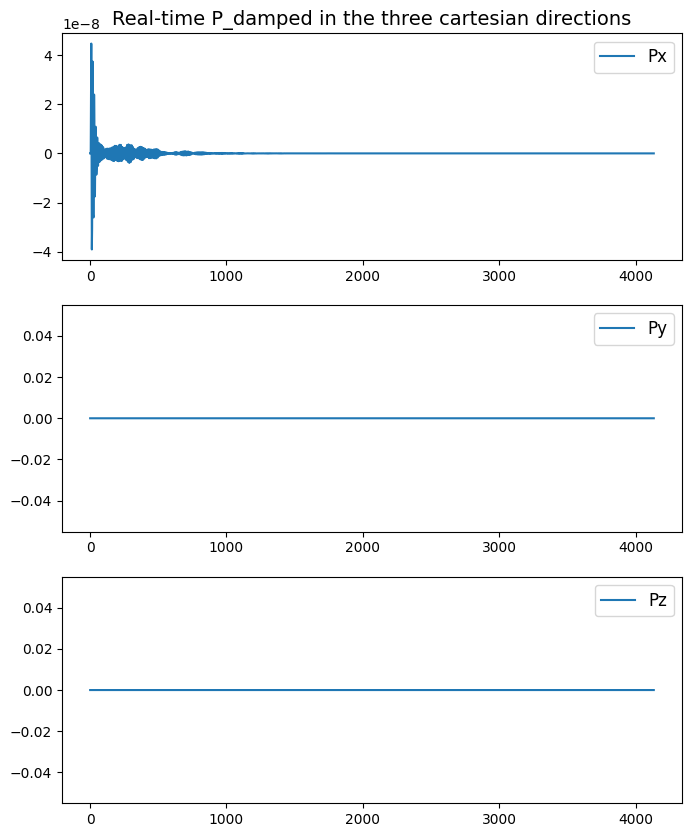

In [110]:
#P_damped = O.damp_ft(P_t,time_fs,t_initial=t_initial_fs,eta=0.7,time_units='fs')
#Plot_3dArray_time(time_fs,P_damped,label='P_damped')
P_damped = O.damp_ft(P_t,time_au,t_initial=t_initial_au,eta=0.7,time_units='au')
Plot_3dArray_time(time_au,P_damped,label='P_damped')

In [111]:
ha2ev = 27.211386

P_damped_yp=np.empty_like(P_t)
for i_d in range(3):
   P_damped_yp[i_d,:]=O.damp_it(P_t[i_d,:],time_au,t_initial_au,damp_type='LORENTZIAN',damp_factor=0.1/ha2ev)

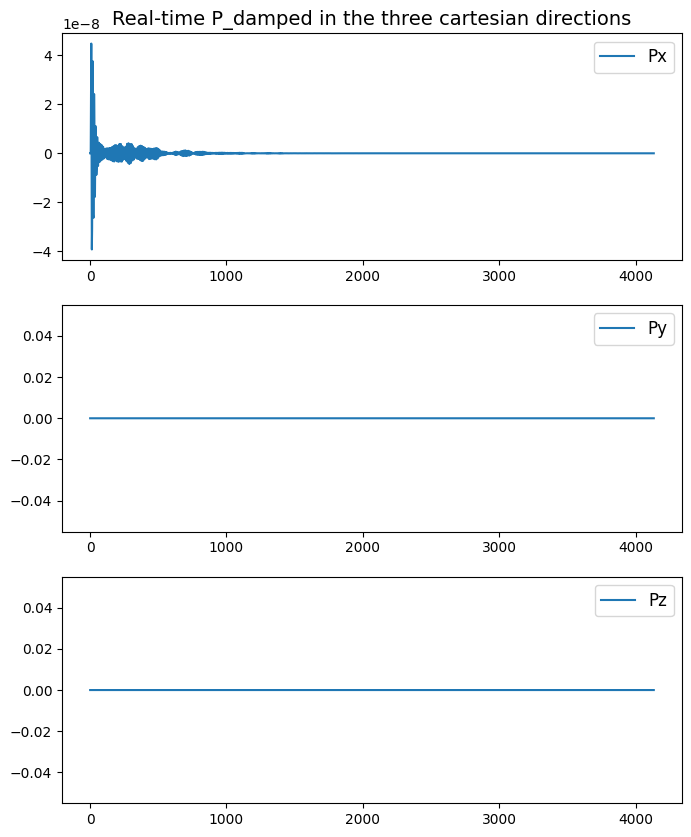

In [112]:
Plot_3dArray_time(time_au,P_damped_yp,label='P_damped')

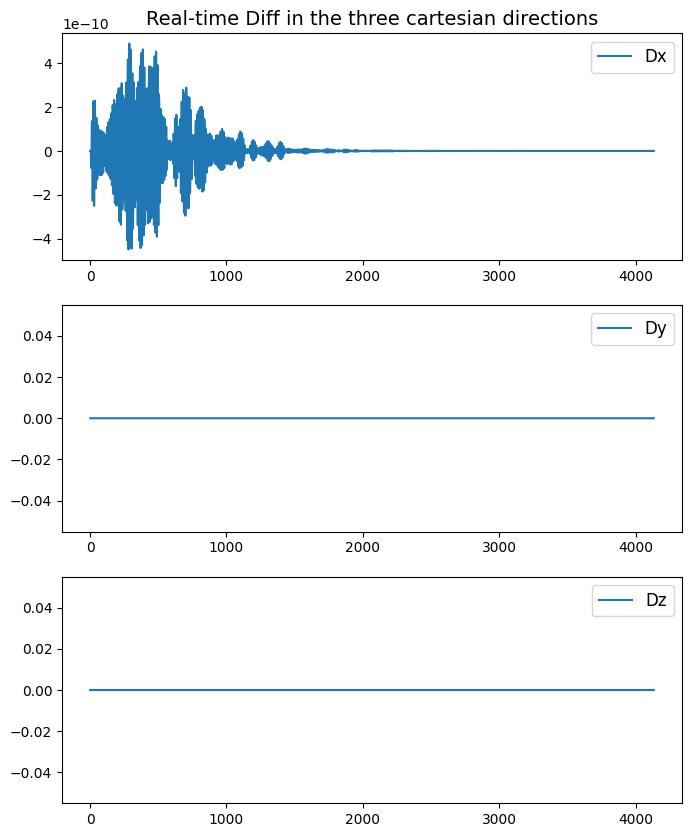

In [121]:
diffe = P_damped-P_damped_yp
Plot_3dArray_time(time_au,diffe,label='Diff')

In [142]:
#e_range = [0,40]
#n_freqs = 200
#freqs=np.linspace(e_range[0],e_range[1],n_freqs)/ha2ev
energy = FT.eval_energy_array(time_au.size,dt=time_au[1]-time_au[0],time_units='au')
Pw = np.fft.rfft(P_damped)

Pw_yp=np.zeros((3,energy.size),dtype=complex)
O.Fourier_Interpolation(P_damped,Pw_yp,time_au,energy,mode="T2W")

Maximum energy value = 1.5190703108508952
Energy sampling step = 0.0015190703108508951


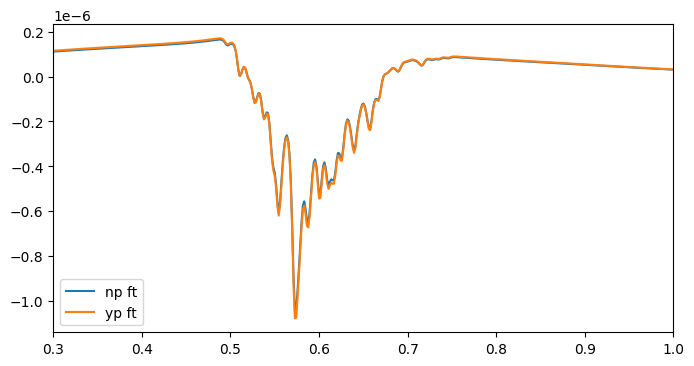

In [155]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(energy,-np.imag(2*Pw[0]),label='np ft')
ax1.plot(energy,np.imag(Pw_yp[0]),label='yp ft')
ax1.set_xlim(0.3,1)
ax1.legend()

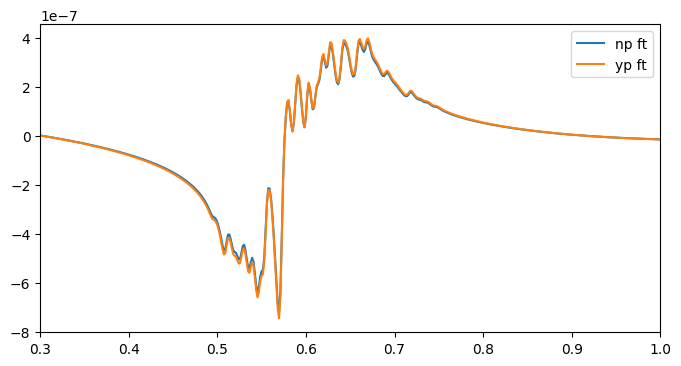

In [154]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(energy,np.real(2*Pw[0]),label='np ft')
ax1.plot(energy,np.real(Pw_yp[0]),label='yp ft')
ax1.set_xlim(0.3,1)
ax1.legend()

In [169]:
energy,chi = O.Linear_Response(time_au,P_t,efield=efield,eta=0.8,time_units='au')

Maximum energy value = 1.5190703108508952
Energy sampling step = 0.0015190703108508951
Damping factor = 0.004679069065923958


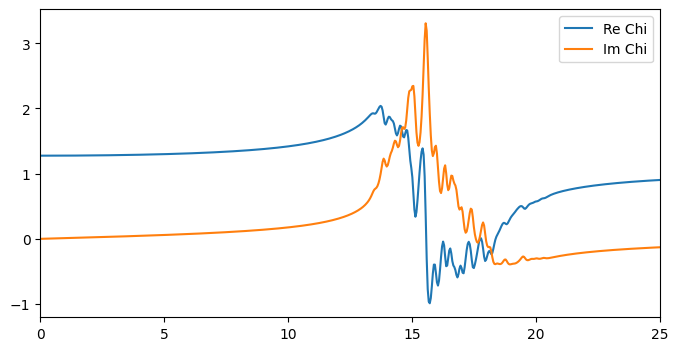

In [170]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(energy,np.real(chi),label='Re Chi')
ax1.plot(energy,np.imag(chi),label='Im Chi')
ax1.set_xlim(0,25)
ax1.legend()

t_initial = 4.1341373336561364


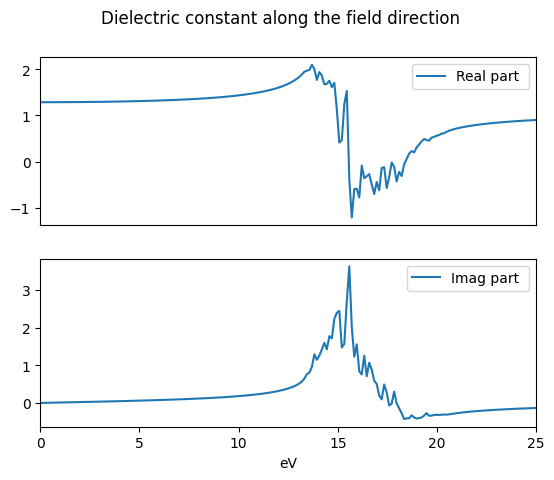

In [171]:
O.YamboPy_Linear_Response(time_au,P_damped,efield,e_range=[0.0, 25.0])

time max = 4134.137333656136 2001
Maximum energy value = 1.5190703108508952
Energy sampling step = 0.0015190703108508951
Damping factor = 0.004679069065923958


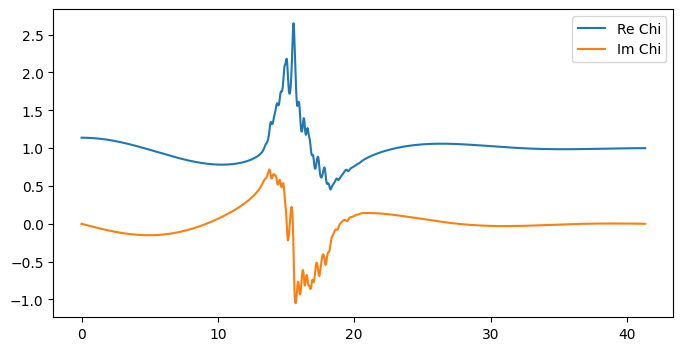

In [10]:
time = data.IO_TIME_points
print('time max =',time[-1])    
Nt = time.size
dt = time[1]-time[0]
freqs = np.fft.rfftfreq(Nt,d=dt)
energy = C.Planck_au*freqs # in Ha
print('energy max =',energy[-1])    
efield_w = O.eval_Efield_w(energy,efield)

time max = 4134.137333656136
energy max = 1.5190703108508952


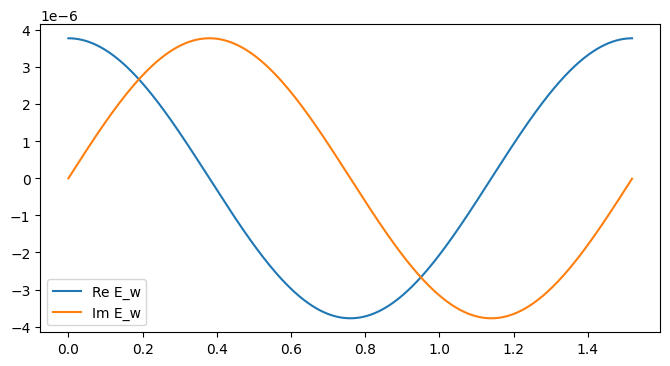

In [11]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(energy,np.real(efield_w),label='Re E_w')
ax1.plot(energy,np.imag(efield_w),label='Im E_w')
#ax1.set_xlim(0,1.4)
ax1.legend()

Analysis performed according to YamboPy

In [20]:
ha2ev = 27.211386

e_range=[0.0, 40.0]
n_freqs=200
freqs=np.linspace(e_range[0],e_range[1],n_freqs)/ha2ev
efield_w_yp=O.get_Efield_w(freqs,efield)
print(freqs[-1])

t_initial = 4.1341373336561364
1.4699729003145963


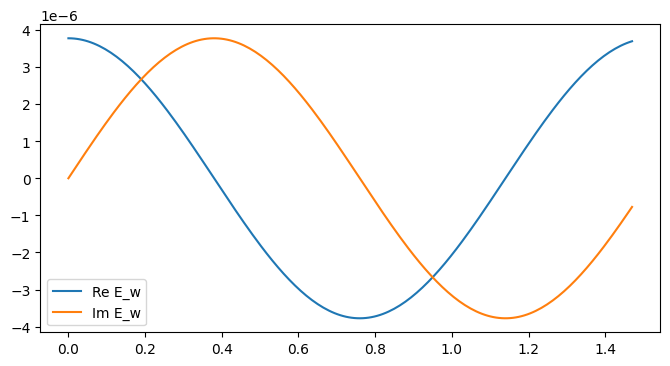

In [21]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(freqs,np.real(efield_w_yp),label='Re E_w')
ax1.plot(freqs,np.imag(efield_w_yp),label='Im E_w')
ax1.legend()

In [75]:
#Plot_3dArray_time(time_au,pol_damped,label='P_damped')

t_initial = 4.1341373336561364


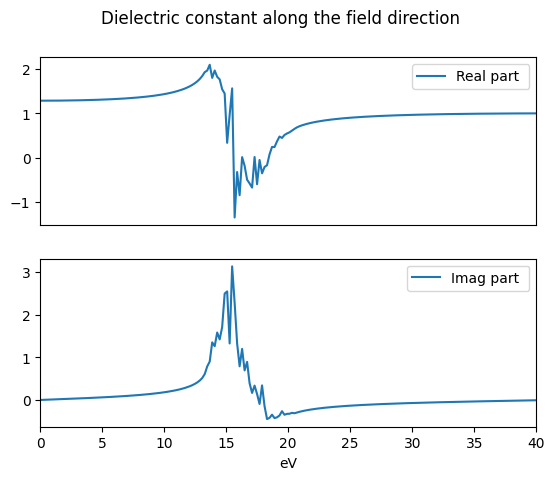